# NBAIoT — ML Classification (Universal)

**Dataset:** [N-BaIoT on Kaggle](https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset)  
**Задача 1:** Бинарная классификация — benign vs malicious  
**Задача 2:** Мультиклассовая — определение типа атаки  

---
### Как настроить ноутбук
Все параметры — в ячейке **«Конфигурация»**:
| Параметр | Что меняет |
|---|---|
| `SAMPLE_FRACTION` | Доля датасета (0.0–1.0). `0.1` = 10%, `1.0` = весь датасет |
| `TEST_SIZE` | Доля тестовой выборки от отобранного объёма |
| `N_TOP_FEATURES` | Число топ-признаков по корреляции с целевой переменной |
| `MODELS` | Словарь алгоритмов — добавляйте/удаляйте без изменения остального кода |

## 0. Конфигурация железа

In [1]:
import platform, subprocess
import psutil

print("=" * 62)
print("КОНФИГУРАЦИЯ")
print("=" * 62)
print(f"Процессор         : {platform.processor()}")

print(f"Ядра CPU (физ.)   : {psutil.cpu_count(logical=False)}")
print(f"Ядра CPU (лог.)   : {psutil.cpu_count(logical=True)}")


ram = psutil.virtual_memory()
print(f"RAM всего         : {ram.total / 1024**3:.2f} ГБ")
print(f"RAM доступно      : {ram.available / 1024**3:.2f} ГБ")

КОНФИГУРАЦИЯ
Процессор         : x86_64
Ядра CPU (физ.)   : 16
Ядра CPU (лог.)   : 32
RAM всего         : 251.89 ГБ
RAM доступно      : 248.51 ГБ


## 1. Импорты и конфигурация

In [31]:
import time, warnings, gc, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Путь к директории с CSV-файлами датасета
DATA_DIR = Path("../datasets")

# Доли датасета, задействованные в обучении и тестах. Диапазон: (0.0, 1.0]
SAMPLE_FRACTIONS = [0.01, 0.05] # 0.1, 0.25, 0.5, 0.75, 1.0]

# Одиночное значение для метрик в секциях 10–14
SAMPLE_FRACTION = SAMPLE_FRACTIONS[-1]

# Количества ядер, задействованные в обучении и тестах
N_JOBS_LIST = [1, 32]

# Одиночное значение для метрик в секциях 10–14
CORES_SAMPLE_FRACTION = SAMPLE_FRACTIONS[1]


# Доля тестовой выборки от отобранных данных
TEST_SIZE = 0.20

# Кол-во топ-признаков по корреляции с целевой переменной (бинарная задача)
N_TOP_FEATURES = 15

RANDOM_STATE = 42
METRICS = ["accuracy", "precision", "recall"]

sns.set_theme(style="whitegrid", palette="muted")
print(f"Конфигурация ноутбука:")
print(f"SAMPLE_FRACTIONS  = {SAMPLE_FRACTIONS}")
print(f"(финальный прогон: {SAMPLE_FRACTION*100:.0f}% датасета)")
print(f"N_JOBS_LIST       = {N_JOBS_LIST}")
print(f"CORES_SAMPLE_FRACTION = {CORES_SAMPLE_FRACTION*100:.0f}% датасета")
print(f"TEST_SIZE        = {TEST_SIZE}")
print(f"N_PCA_COMPONENTS = {N_PCA_COMPONENTS}")
print(f"RANDOM_STATE     = {RANDOM_STATE}")

Конфигурация ноутбука:
SAMPLE_FRACTIONS  = [0.01, 0.05]
(финальный прогон: 5% датасета)
N_JOBS_LIST       = [1, 32]
CORES_SAMPLE_FRACTION = 5% датасета
TEST_SIZE        = 0.2
N_PCA_COMPONENTS = 17
RANDOM_STATE     = 42


## 2. Загрузка данных

In [3]:
BENIGN_KEYWORDS = ["benign"]

csv_files = sorted(DATA_DIR.rglob("*.csv"))
assert len(csv_files) > 0, f"CSV-файлы не найдены в {DATA_DIR}!"
print(f"Найдено CSV-файлов: {len(csv_files)}")

frames = []
for fpath in csv_files:
    df_tmp = pd.read_csv(fpath)
    stem   = fpath.stem.lower()
    parent = fpath.parent.name.lower()

    is_benign   = any(kw in stem or kw in parent for kw in BENIGN_KEYWORDS)
    clean_stem  = stem.lstrip("0123456789.").strip().replace(" ", "_")
    label_multi = "benign" if is_benign else (clean_stem or parent)

    df_tmp["label_multi"]  = label_multi
    df_tmp["label_binary"] = 0 if is_benign else 1

    frames.append(df_tmp)
    print(f"  {len(df_tmp):>8,} строк  label='{label_multi}'  [{fpath.name}]")

df = pd.concat(frames, ignore_index=True)
print(f"\nИтого загружено: {df.shape[0]:,} строк × {df.shape[1]} колонок")
del frames; gc.collect()

Найдено CSV-файлов: 89
    49,548 строк  label='benign'  [1.benign.csv]
    59,718 строк  label='gafgyt.combo'  [1.gafgyt.combo.csv]
    29,068 строк  label='gafgyt.junk'  [1.gafgyt.junk.csv]
    29,849 строк  label='gafgyt.scan'  [1.gafgyt.scan.csv]
    92,141 строк  label='gafgyt.tcp'  [1.gafgyt.tcp.csv]
   105,874 строк  label='gafgyt.udp'  [1.gafgyt.udp.csv]
   102,195 строк  label='mirai.ack'  [1.mirai.ack.csv]
   107,685 строк  label='mirai.scan'  [1.mirai.scan.csv]
   122,573 строк  label='mirai.syn'  [1.mirai.syn.csv]
   237,665 строк  label='mirai.udp'  [1.mirai.udp.csv]
    81,982 строк  label='mirai.udpplain'  [1.mirai.udpplain.csv]
    13,113 строк  label='benign'  [2.benign.csv]
    53,012 строк  label='gafgyt.combo'  [2.gafgyt.combo.csv]
    30,312 строк  label='gafgyt.junk'  [2.gafgyt.junk.csv]
    27,494 строк  label='gafgyt.scan'  [2.gafgyt.scan.csv]
    95,021 строк  label='gafgyt.tcp'  [2.gafgyt.tcp.csv]
   104,791 строк  label='gafgyt.udp'  [2.gafgyt.udp.csv]
   113

24

## 3. Вспомогательные функции

In [29]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       task="binary", class_names=None,
                       algo_name="", feature_mode=""):
    """
    Обучает модель и возвращает словарь с метриками и предсказаниями.
    Использует clone() — исходный объект модели не изменяется.
    """
    avg     = "binary" if task == "binary" else "weighted"
    m       = clone(model)              # свежая копия, без предыдущих весов

    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    y_pred   = m.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=avg, zero_division=0)
    recall    = recall_score(y_test, y_pred, average=avg, zero_division=0)

    avg_tag = "" if task == "binary" else " (weighted)"
    print(f"  [{feature_mode}] {algo_name} / {task}")
    print(f"    Время обучения : {train_time:.2f}с")
    print(f"    Accuracy       : {accuracy:.4f}")
    print(f"    Precision      : {precision:.4f}{avg_tag}")
    print(f"    Recall         : {recall:.4f}{avg_tag}")

    if class_names is not None and task != "binary":
        print()
        print(classification_report(
            y_test, y_pred, target_names=class_names, zero_division=0
        ))

    return {
        "model":      m,
        "y_pred":     y_pred,
        "accuracy":   accuracy,
        "precision":  precision,
        "recall":     recall,
        "train_time": train_time,
    }


def build_summary(all_results, task):
    """
    Строит DataFrame с метриками по всем алгоритмам и режимам признаков.
    all_results: {algo_name: {feature_mode: {task: result_dict}}}
    """
    rows = []
    for algo_name, modes in all_results.items():
        for feature_mode, tasks in modes.items():
            res = tasks[task]
            rows.append({
                "Алгоритм":       algo_name,
                "Признаки":       feature_mode,
                "Accuracy":       res["accuracy"],
                "Precision":      res["precision"],
                "Recall":         res["recall"],
                "Train time (s)": res["train_time"],
            })
    return pd.DataFrame(rows)


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm  = confusion_matrix(y_true, y_pred)
    sz  = max(6, len(class_names))
    fig, ax = plt.subplots(figsize=(sz, sz - 1))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, colorbar=True, cmap="Blues", xticks_rotation="vertical"
    )
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison(df_summary, task_label):
    """
    Строит сгруппированный bar-chart для всех алгоритмов из df_summary.
    Работает для любого кол-ва алгоритмов и режимов признаков.
    """
    # Создаём составной ключ «Алгоритм / Признаки» для оси X
    df_plot = df_summary.copy()
    df_plot["label"] = df_plot["Алгоритм"] + "\n" + df_plot["Признаки"]

    n_groups  = len(df_plot)
    n_metrics = len(METRICS)
    x         = np.arange(n_groups)
    width     = 0.22
    colors    = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 1.5), 5))
    for i, metric in enumerate(METRICS):
        vals = df_plot[metric.capitalize()].values
        bars = ax.bar(
            x + i * width, vals, width,
            label=metric.capitalize(),
            color=colors[i % len(colors)],
            edgecolor="k", linewidth=0.5
        )
        for b in bars:
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + 0.005,
                f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=7
            )

    ax.set_xticks(x + width * (n_metrics - 1) / 2)
    ax.set_xticklabels(df_plot["label"], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"{task_label} — сравнение метрик", fontweight="bold")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


def plot_train_time_comparison(df_summary, task_label):
    """
    Pivot-bar: алгоритм vs режим признаков (full / pca).
    Работает для любого кол-ва алгоритмов.
    """
    pivot = df_summary.pivot(index="Алгоритм", columns="Признаки", values="Train time (s)")
    ax    = pivot.plot(kind="bar", figsize=(max(8, len(pivot) * 2), 4),
                       edgecolor="k", linewidth=0.5)
    ax.set_title(f"{task_label} — время обучения", fontweight="bold")
    ax.set_ylabel("Секунды")
    ax.set_xlabel("")
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title, top_n=20):
    """
    Строит bar-chart важности признаков, если модель поддерживает feature_importances_.
    """
    if not hasattr(model, "feature_importances_"):
        print(f"  Пропущено: {title!r} не поддерживает feature_importances_")
        return

    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(indices)), importances[indices], color="steelblue", edgecolor="k")
    ax.set_xticks(range(len(indices)))
    ax.set_xticklabels(
        [feature_names[i] for i in indices],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_title(f"Топ-{top_n} важных признаков — {title}", fontweight="bold")
    ax.set_ylabel("Важность")
    plt.tight_layout()
    plt.show()


print("Все вспомогательные функции определены")

Все вспомогательные функции определены


## 4. Перебор размеров датасета

Для каждой доли из `SAMPLE_FRACTIONS` последовательно выполняется:  
выборка → предобработка → масштабирование + отбор топ-признаков по корреляции → разбивка → обучение всех моделей.  
Все временны́е и качественные метрики фиксируются в `scaling_results`.

In [32]:
# scaling_results[fraction] = {algo_name: {feature_mode: {task: result_dict}}}
scaling_results = {}

for SAMPLE_FRACTION in SAMPLE_FRACTIONS:

    print(f"\n{'#'*62}")
    print(f"  ПРОГОН: {SAMPLE_FRACTION*100:.0f}% датасета")
    print(f"{'#'*62}")

    # Выборка
    total_rows = len(df)
    if SAMPLE_FRACTION < 1.0:
        df_sample, _ = train_test_split(
            df,
            train_size=SAMPLE_FRACTION,
            random_state=RANDOM_STATE,
            stratify=df["label_binary"]
        )
        df_sample = df_sample.reset_index(drop=True)
    else:
        df_sample = df.copy()

    sampled_rows = len(df_sample)
    print(f"  Строк после выборки: {sampled_rows:,} ({sampled_rows/total_rows*100:.1f}%)")

    # Предобработка
    FEATURE_COLS_run = [c for c in df_sample.columns if c not in ("label_binary", "label_multi")]

    df_sample = df_sample.drop_duplicates(subset=FEATURE_COLS_run).reset_index(drop=True)

    std_vals = df_sample[FEATURE_COLS_run].std()
    const_feats = std_vals[std_vals == 0].index.tolist()
    if const_feats:
        FEATURE_COLS_run = [c for c in FEATURE_COLS_run if c not in const_feats]

    df_sample[FEATURE_COLS_run] = df_sample[FEATURE_COLS_run].fillna(0)

    y_bin_run   = df_sample["label_binary"].values
    y_multi_run = df_sample["label_multi"].values

    le_run = LabelEncoder()
    y_multi_enc_run = le_run.fit_transform(y_multi_run)
    n_classes_run   = len(le_run.classes_)

    bin_counts_run      = pd.Series(y_bin_run).value_counts()
    scale_pos_weight_run = int(bin_counts_run[0]) / int(bin_counts_run[1])

    # Масштабирование и отбор топ-признаков по корреляции
    X_raw_run = df_sample[FEATURE_COLS_run].values.astype(np.float32)

    robust_scaler_run = RobustScaler()
    X_robust_run = robust_scaler_run.fit_transform(X_raw_run).astype(np.float32)

    # Отбор топ-N признаков по абсолютной корреляции с бинарной целевой переменной
    corr_series = (
        pd.DataFrame(X_raw_run, columns=FEATURE_COLS_run)
        .corrwith(pd.Series(y_bin_run.astype(float)))
        .abs()
    )
    top_feat_idx_run = corr_series.nlargest(N_TOP_FEATURES).index.tolist()
    top_feat_pos_run = [FEATURE_COLS_run.index(f) for f in top_feat_idx_run]
    X_top_run = X_robust_run[:, top_feat_pos_run]   # уже масштабированы
    print(f"  Топ-{N_TOP_FEATURES} признаков: {top_feat_idx_run[:5]} ...")

    # Разбивка train / test
    split_kw_b_run = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin_run)
    split_kw_m_run = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_multi_enc_run)

    Xr_tr_b_r, Xr_te_b_r, y_tr_b_r, y_te_b_r = train_test_split(X_robust_run, y_bin_run,       **split_kw_b_run)
    Xr_tr_m_r, Xr_te_m_r, y_tr_m_r, y_te_m_r = train_test_split(X_robust_run, y_multi_enc_run, **split_kw_m_run)
    Xt_tr_b_r, Xt_te_b_r, _,        _         = train_test_split(X_top_run,    y_bin_run,       **split_kw_b_run)
    Xt_tr_m_r, Xt_te_m_r, _,        _         = train_test_split(X_top_run,    y_multi_enc_run, **split_kw_m_run)

    DATASETS_run = {
        "full": {
            "binary":     (Xr_tr_b_r, Xr_te_b_r, y_tr_b_r, y_te_b_r),
            "multiclass": (Xr_tr_m_r, Xr_te_m_r, y_tr_m_r, y_te_m_r),
        },
        f"top{N_TOP_FEATURES}": {
            "binary":     (Xt_tr_b_r, Xt_te_b_r, y_tr_b_r, y_te_b_r),
            "multiclass": (Xt_tr_m_r, Xt_te_m_r, y_tr_m_r, y_te_m_r),
        },
    }

    # Реестр алгоритмов
    MODELS_run = {
        "Decision Tree": {
            "binary":     DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                              class_weight="balanced", random_state=RANDOM_STATE),
            "multiclass": DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                              class_weight="balanced", random_state=RANDOM_STATE),
        },
        "Random Forest": {
            "binary":     RandomForestClassifier(n_estimators=100, max_depth=6,
                              min_samples_leaf=5, class_weight="balanced",
                              n_jobs=-1, random_state=RANDOM_STATE),
            "multiclass": RandomForestClassifier(n_estimators=100, max_depth=6,
                              min_samples_leaf=5, class_weight="balanced",
                              n_jobs=-1, random_state=RANDOM_STATE),
        },
        "XGBoost (CPU)": {
            "binary":     XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=scale_pos_weight_run,
                              tree_method="hist", device="cpu",
                              eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
            "multiclass": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              objective="multi:softmax", num_class=n_classes_run,
                              tree_method="hist", device="cpu",
                              eval_metric="mlogloss", random_state=RANDOM_STATE, verbosity=0),
        },
    }

    # Обучение (цикл по моделям)
    all_results_run = {}
    for algo_name, algo_models in MODELS_run.items():
        all_results_run[algo_name] = {}
        for feature_mode, task_datasets in DATASETS_run.items():
            all_results_run[algo_name][feature_mode] = {}
            for task, (X_tr, X_te, y_tr, y_te) in task_datasets.items():
                result = train_and_evaluate(
                    model=algo_models[task],
                    X_train=X_tr, y_train=y_tr,
                    X_test=X_te,  y_test=y_te,
                    task=task,
                    algo_name=algo_name,
                    feature_mode=feature_mode,
                )
                all_results_run[algo_name][feature_mode][task] = result

    scaling_results[SAMPLE_FRACTION] = all_results_run

    # Сохраняем переменные последнего прогона для секций 10–14
    if SAMPLE_FRACTION == SAMPLE_FRACTIONS[-1]:
        all_results      = all_results_run
        DATASETS         = DATASETS_run
        FEATURE_COLS     = FEATURE_COLS_run
        TOP_FEATURES     = top_feat_idx_run
        le               = le_run
        sampled_rows     = len(df_sample)
        CLASS_NAMES  = {
            "binary":     ["Benign", "Malicious"],
            "multiclass": le.classes_,
        }

    gc.collect()

print("\nВсе прогоны завершены")
print(f"Размеры датасета: {[f'{f*100:.0f}%' for f in SAMPLE_FRACTIONS]}")



##############################################################
  ПРОГОН: 1% датасета
##############################################################
  Строк после выборки: 70,626 (1.0%)
  Топ-15 признаков: ['HH_L0.01_std', 'HH_L0.1_std', 'MI_dir_L0.1_weight', 'H_L0.1_weight', 'MI_dir_L1_weight'] ...
  [full] Decision Tree / binary
    Время обучения : 1.80с
    Accuracy       : 0.9988
    Precision      : 0.9994
    Recall         : 0.9993
  [full] Decision Tree / multiclass
    Время обучения : 1.83с
    Accuracy       : 0.7569
    Precision      : 0.7375 (weighted)
    Recall         : 0.7569 (weighted)
  [top15] Decision Tree / binary
    Время обучения : 0.26с
    Accuracy       : 0.9994
    Precision      : 0.9998
    Recall         : 0.9995
  [top15] Decision Tree / multiclass
    Время обучения : 0.40с
    Accuracy       : 0.5174
    Precision      : 0.4121 (weighted)
    Recall         : 0.5174 (weighted)
  [full] Random Forest / binary
    Время обучения : 0.57с
    Accuracy  

## 5. Сводные таблицы метрик (последний прогон)

Данные последней итерации `SAMPLE_FRACTIONS`

In [33]:
df_binary    = build_summary(all_results, "binary")
df_multiclass = build_summary(all_results, "multiclass")

fmt = "{:.4f}".format

print("\nБИНАРНАЯ КЛАССИФИКАЦИЯ")
print(df_binary.to_string(index=False, float_format=fmt))

print("\nМУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ")
print(df_multiclass.to_string(index=False, float_format=fmt))

# Лучшие модели
best_bin   = df_binary.loc[df_binary["Accuracy"].idxmax()]
best_multi = df_multiclass.loc[df_multiclass["Accuracy"].idxmax()]


БИНАРНАЯ КЛАССИФИКАЦИЯ
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9994     0.9996  0.9998          9.3249
Decision Tree    top15    0.9996     0.9999  0.9996          1.5228
Random Forest     full    0.9997     1.0000  0.9997          3.0948
Random Forest    top15    0.9995     0.9999  0.9996          1.3107
XGBoost (CPU)     full    0.9998     1.0000  0.9998          0.8924
XGBoost (CPU)    top15    0.9994     0.9998  0.9996          0.3106

МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.8481     0.8062  0.8481          8.7694
Decision Tree    top15    0.5085     0.4046  0.5085          2.2820
Random Forest     full    0.8774     0.8243  0.8774          3.7795
Random Forest    top15    0.7348     0.7116  0.7348          2.2048
XGBoost (CPU)     full    0.9969     0.9970  0.9969          7.5820
XGBoost (CPU)    top15    0.8542     0.8843  0.8542          

## 6. Графики метрик (последний прогон)

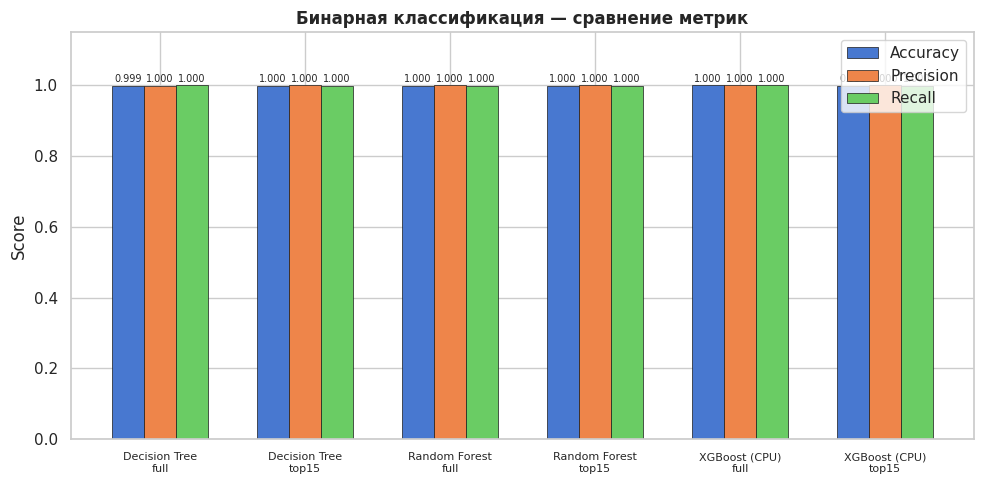

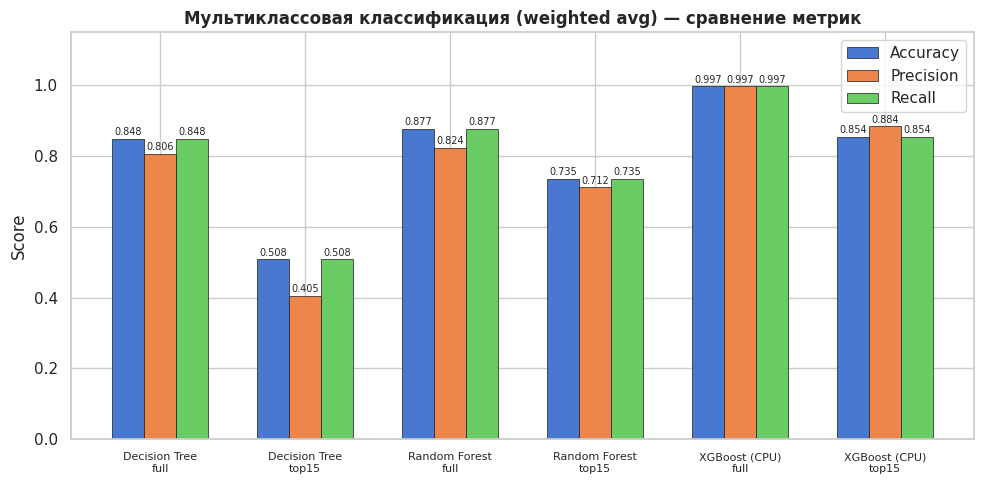

In [34]:
plot_metrics_comparison(
    df_binary,
    task_label="Бинарная классификация"
)

plot_metrics_comparison(
    df_multiclass,
    task_label="Мультиклассовая классификация (weighted avg)"
)

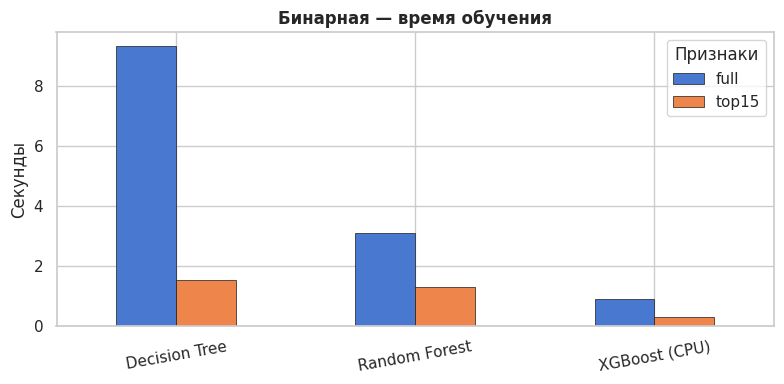

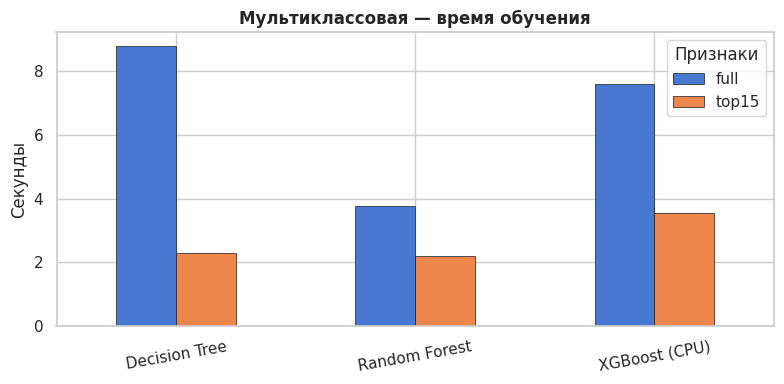

In [36]:
plot_train_time_comparison(
    df_binary,
    task_label="Бинарная"
)

plot_train_time_comparison(
    df_multiclass,
    task_label="Мультиклассовая"
)

## 7. Матрицы ошибок

Генерируются **автоматически** для каждого алгоритма × каждого режима признаков.

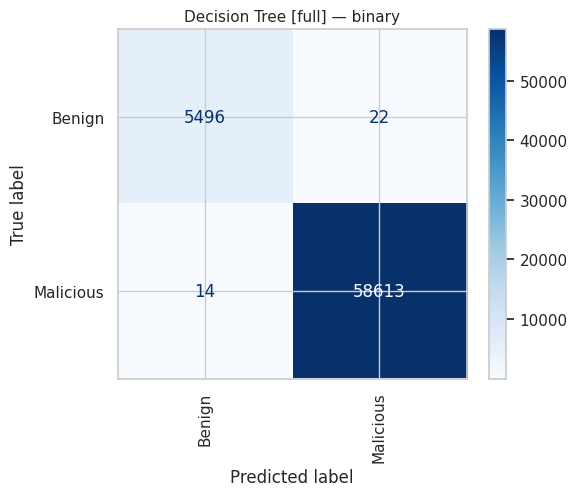

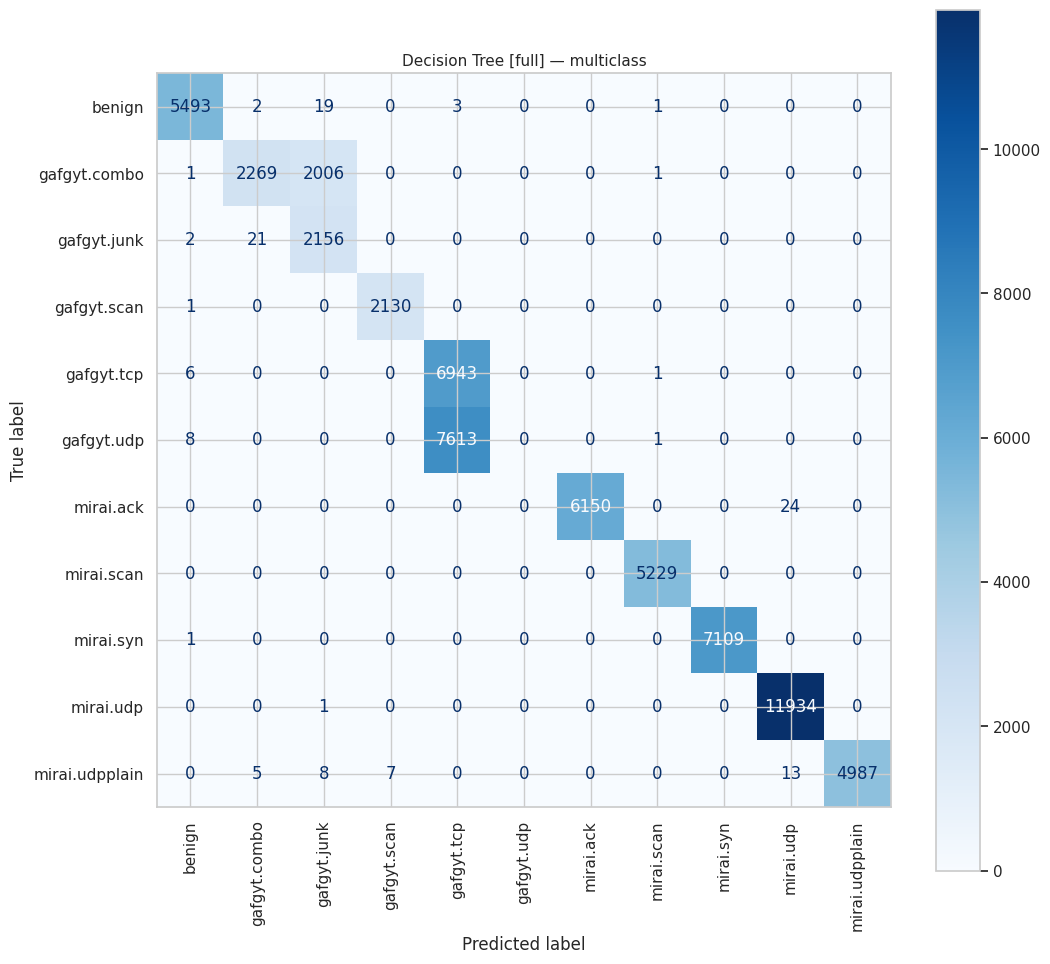

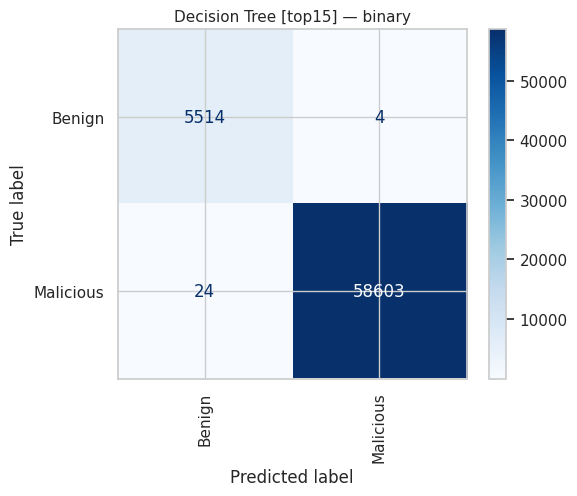

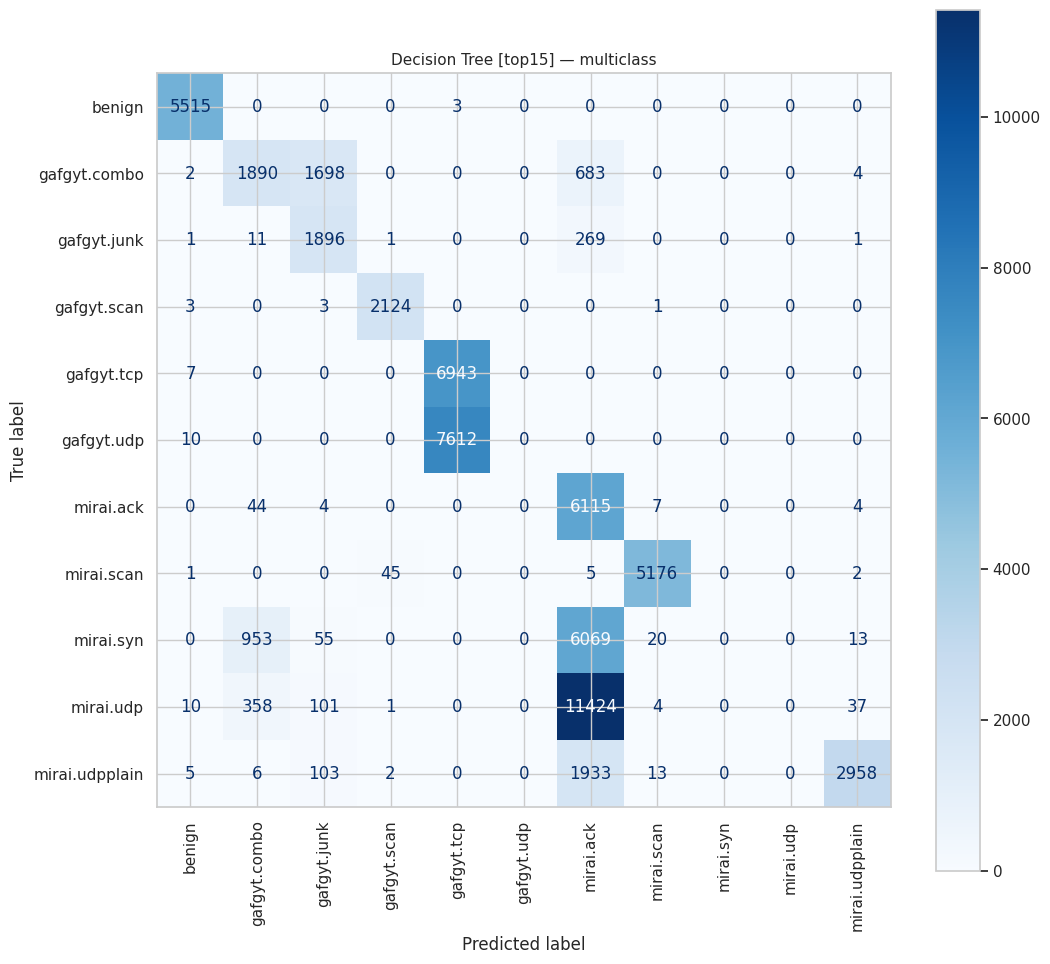

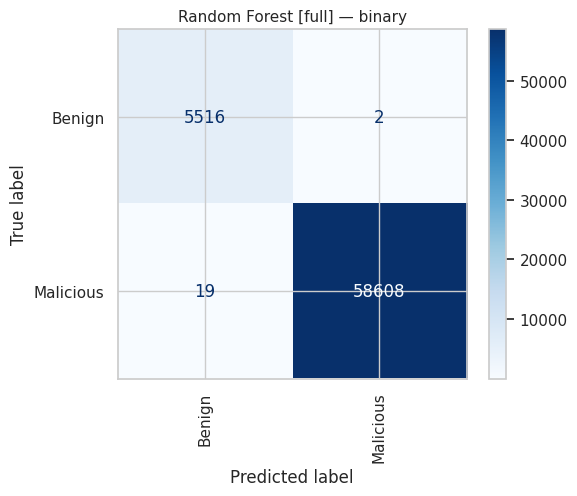

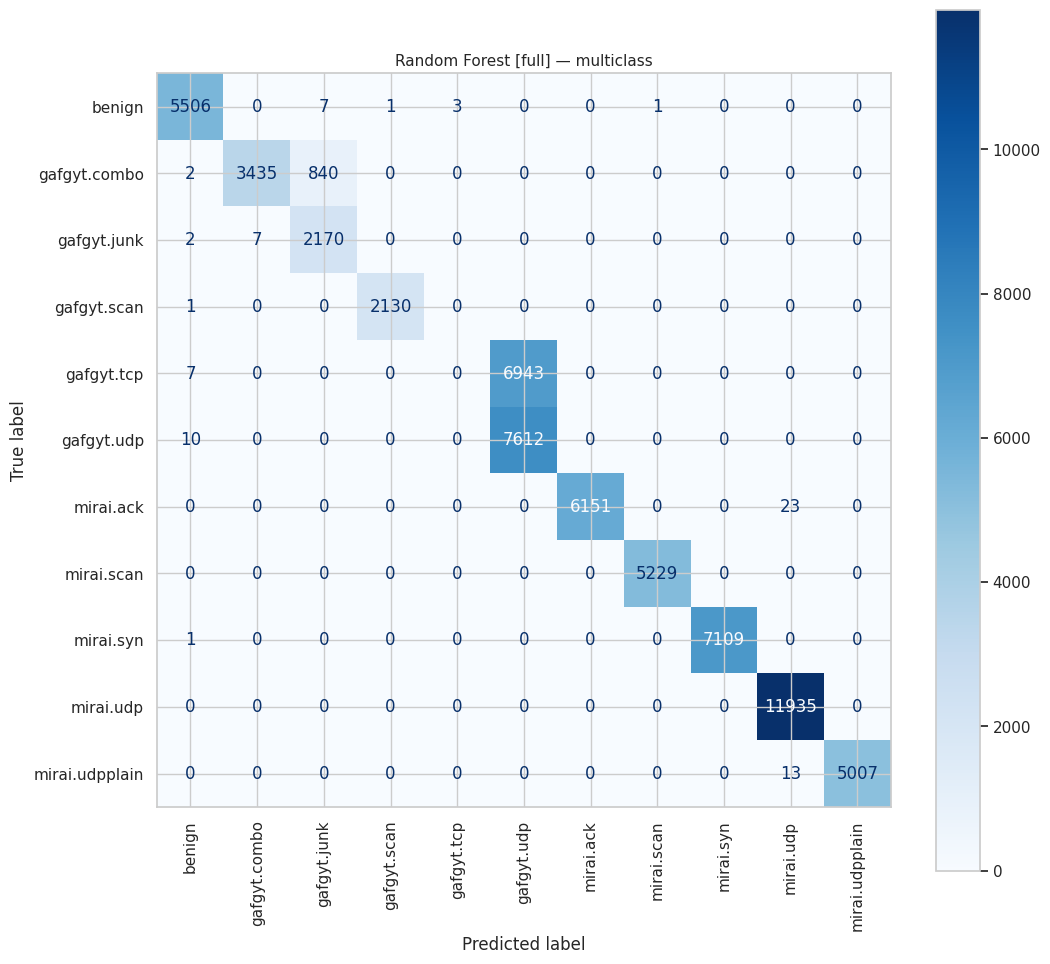

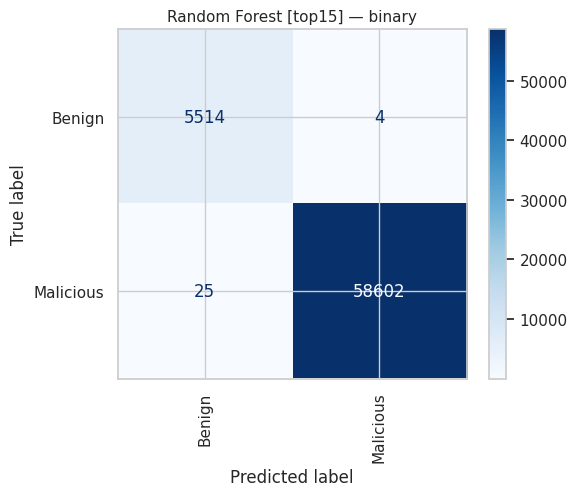

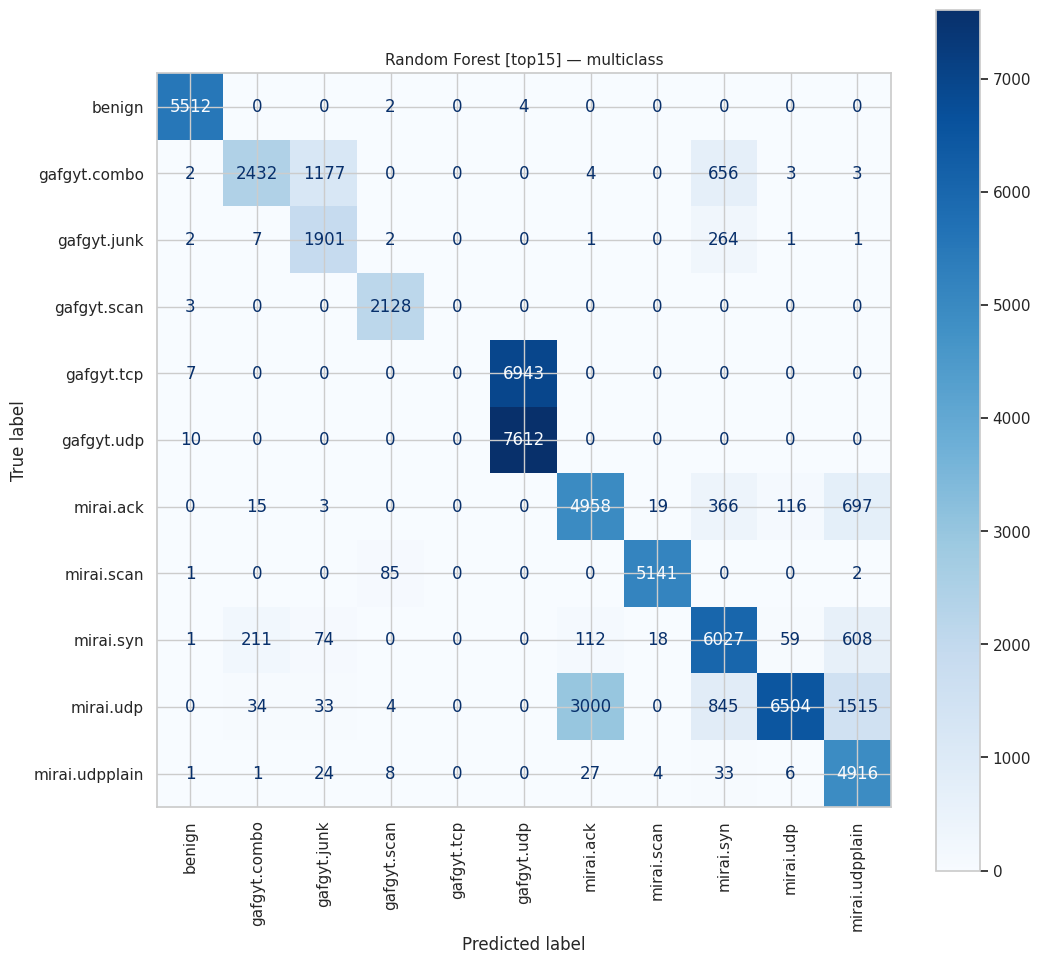

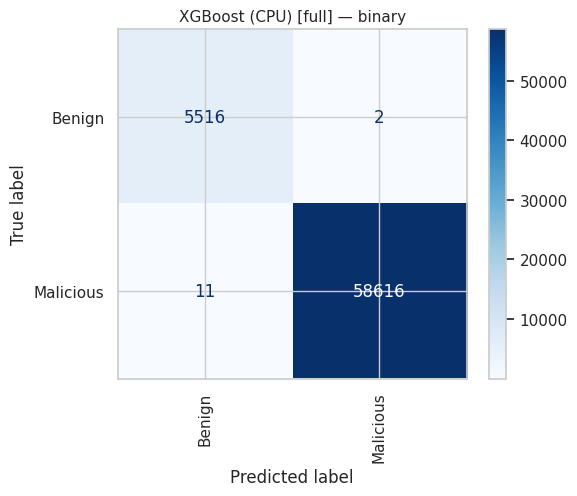

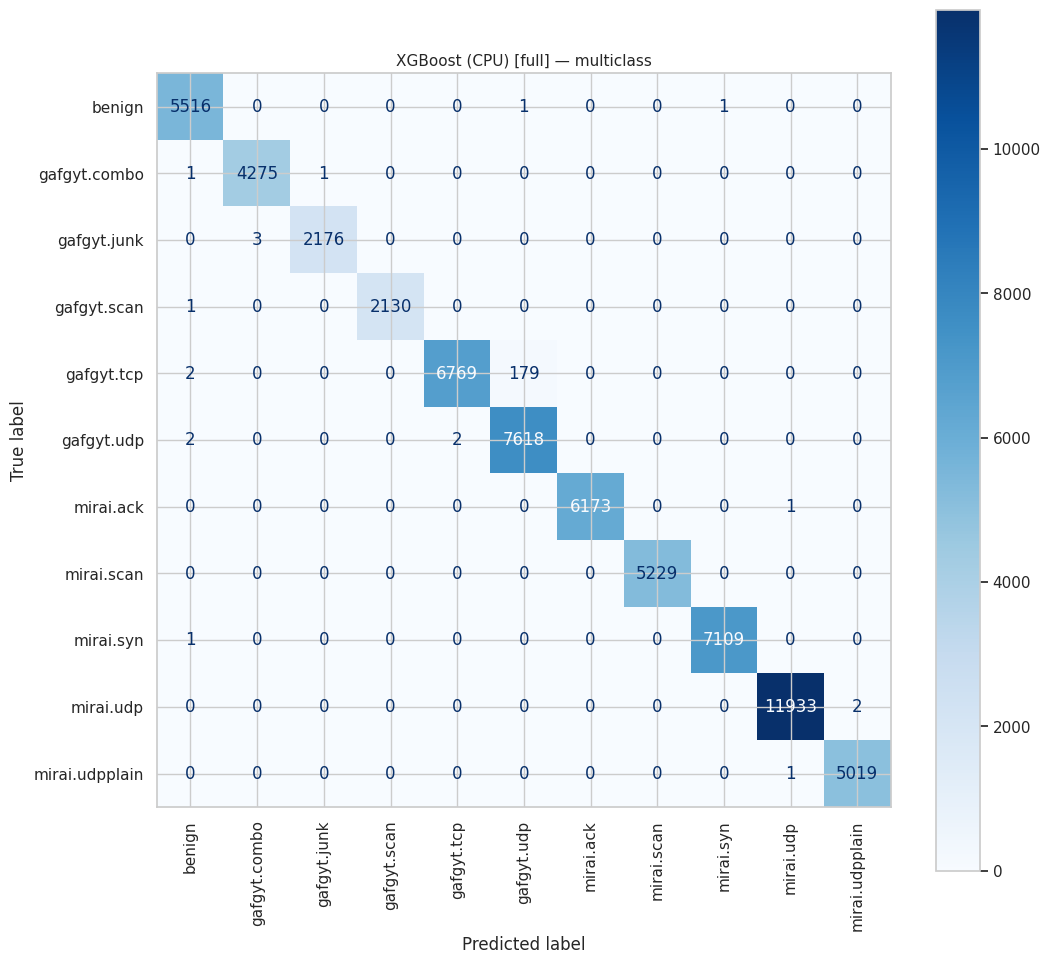

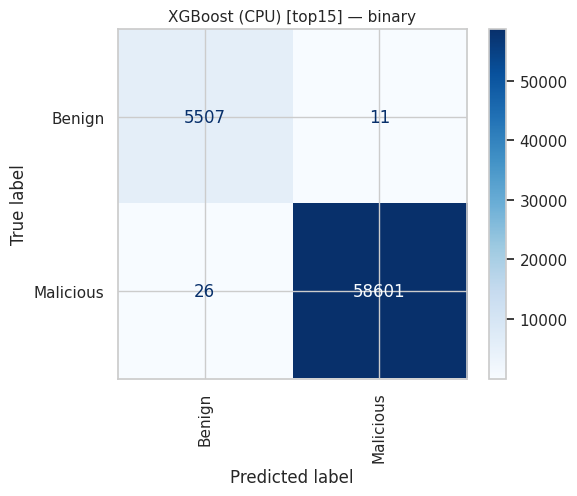

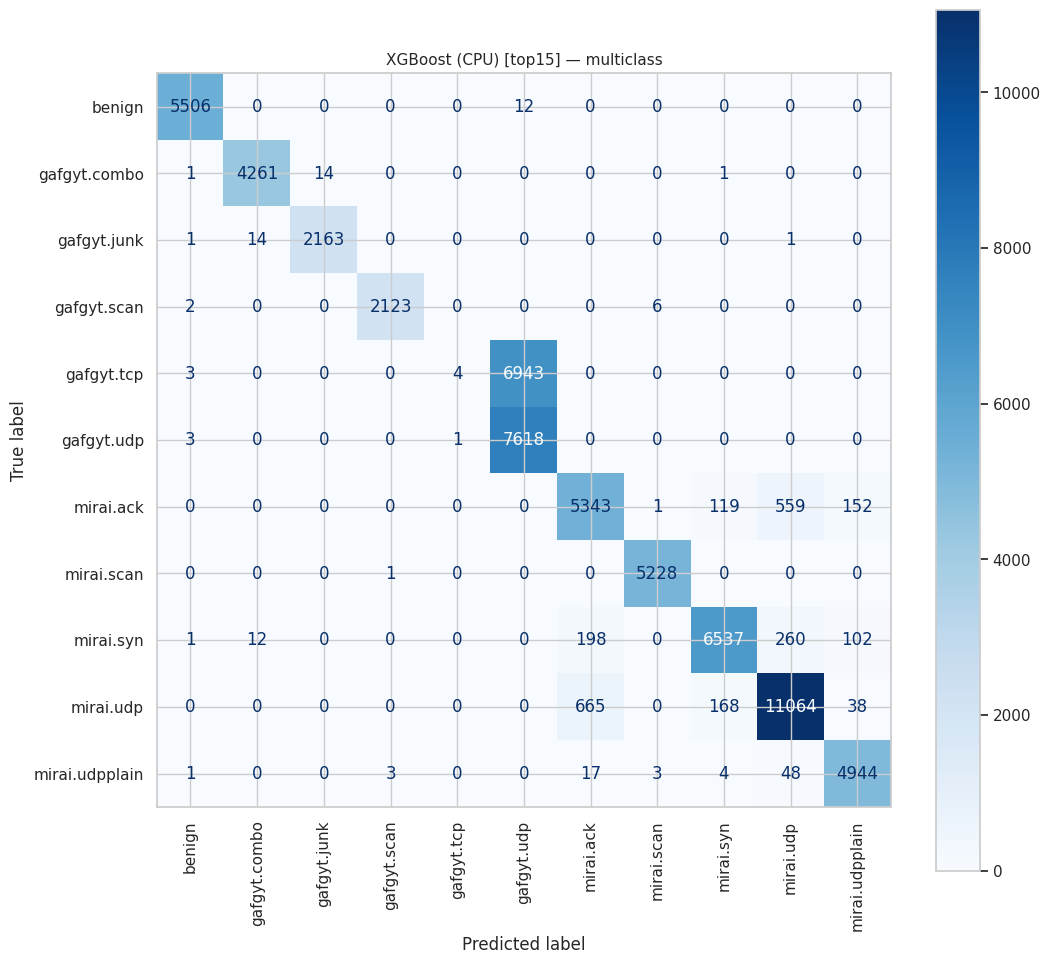

In [37]:
y_test_by_task = {
    task: list(DATASETS.values())[0][task][3] # (y_test4-й элемент кортежа)
    for task in ["binary", "multiclass"]
}

for algo_name, modes in all_results.items():
    for feature_mode, tasks in modes.items():
        for task, res in tasks.items():

            plot_confusion_matrix(
                y_true      = y_test_by_task[task],
                y_pred      = res["y_pred"],
                class_names = CLASS_NAMES[task],
                title       = f"{algo_name} [{feature_mode}] — {task}"
            )

## 8. Финальный отчёт

In [40]:
print("=" * 72)
print("  ФИНАЛЬНЫЙ ОТЧЁТ")
print("=" * 72)
print(f"  Датасет        : {SAMPLE_FRACTION*100:.0f}% от исходного ({sampled_rows:,} строк)")
print(f"  Train/Test     : {(1-TEST_SIZE)*100:.0f}% / {TEST_SIZE*100:.0f}%")
print(f"  Топ-признаков  : {N_TOP_FEATURES} (по корреляции с бин. меткой)")
print(f"  Топ-признаки   : {TOP_FEATURES}")
print(f"  Алгоритмов     : {len(list(MODELS_run.keys()))}: {', '.join(MODELS_run.keys())}")

print("\nБИНАРНАЯ КЛАССИФИКАЦИЯ")
print(df_binary.to_string(index=False, float_format="{:.4f}".format))

print("\nМУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ")
print(df_multiclass.to_string(index=False, float_format="{:.4f}".format))

print("\nУскорение обучения: все vs top признаки")
pca_mode = f"top{N_TOP_FEATURES}"
for algo_name in list(MODELS_run.keys()):
    row_full = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]=="full")]
    row_pca  = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]==pca_mode)]
    if row_full.empty or row_pca.empty:
        continue
    t_full  = row_full["Train time (s)"].values[0]
    t_pca   = row_pca["Train time (s)"].values[0]
    speedup = t_full / t_pca if t_pca > 0 else float("inf")
    delta_acc = (row_pca["Accuracy"].values[0] - row_full["Accuracy"].values[0]) * 100
    sign      = "+" if delta_acc >= 0 else ""
    print(f"{algo_name:<12}: full {t_full:6.2f}с → top {t_pca:6.2f}с  "
          f"(x{speedup:.1f} быстрее)  ΔAccuracy={sign}{delta_acc:.2f}")
    
    
# @TODO Утечка через scaler и отбор признаков — в строгой схеме и RobustScaler, 
# и отбор топ-признаков должны фититься только на train, затем применяться к test через transform.

  ФИНАЛЬНЫЙ ОТЧЁТ
  Датасет        : 5% от исходного (320,721 строк)
  Train/Test     : 80% / 20%
  Топ-признаков  : 15 (по корреляции с бин. меткой)
  Топ-признаки   : ['HH_L0.01_std', 'HH_L0.1_std', 'MI_dir_L0.1_weight', 'H_L0.1_weight', 'MI_dir_L1_weight', 'H_L1_weight', 'MI_dir_L3_weight', 'H_L3_weight', 'MI_dir_L5_weight', 'H_L5_weight', 'HpHp_L0.01_std', 'MI_dir_L0.01_weight', 'H_L0.01_weight', 'HH_L1_std', 'HH_L0.01_radius']
  Алгоритмов     : 3: Decision Tree, Random Forest, XGBoost (CPU)

БИНАРНАЯ КЛАССИФИКАЦИЯ
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9994     0.9996  0.9998          9.3249
Decision Tree    top15    0.9996     0.9999  0.9996          1.5228
Random Forest     full    0.9997     1.0000  0.9997          3.0948
Random Forest    top15    0.9995     0.9999  0.9996          1.3107
XGBoost (CPU)     full    0.9998     1.0000  0.9998          0.8924
XGBoost (CPU)    top15    0.9994     0.9998  0.9996          0.310

## 9. График: время обучения vs размер датасета

Визуализирует зависимость времени обучения от доли используемого датасета для каждого алгоритма (full features и top-15 по корреляции), отдельно для бинарной и мультиклассовой задач

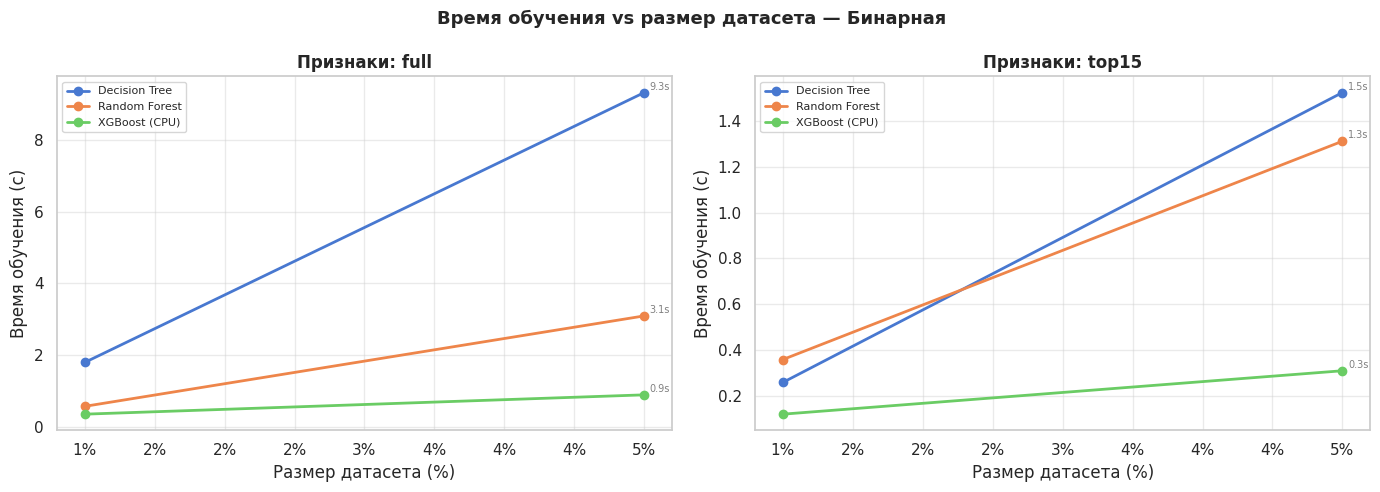

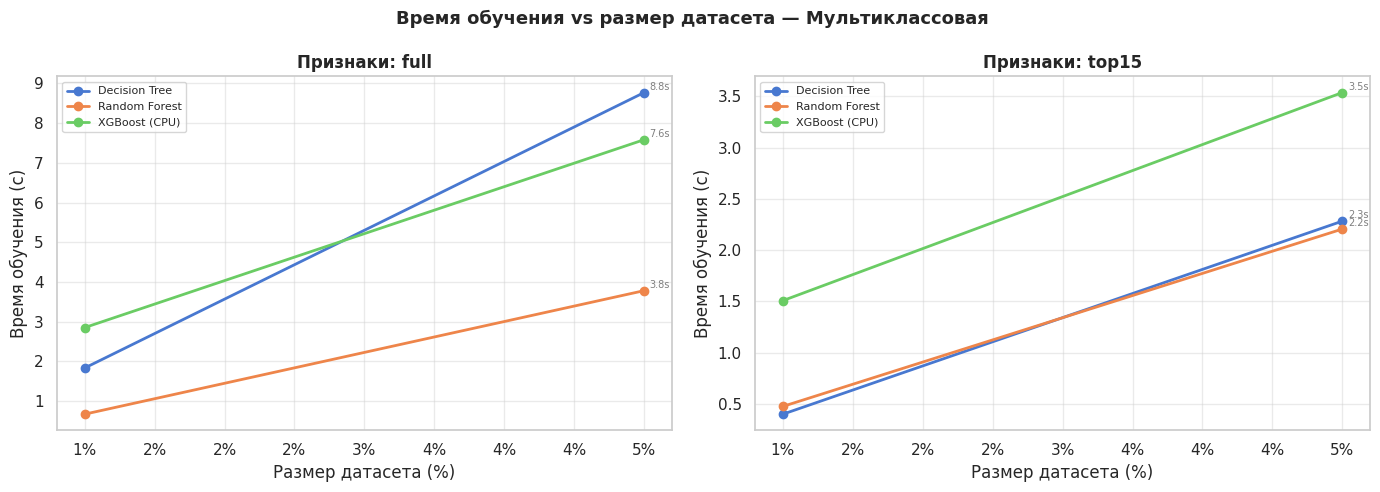


Время обучения (сек) по прогонам
Алгоритм               |     1% |     5%
-------------------------------------------
Decision Tree          |   1.80 |   9.32
Random Forest          |   0.57 |   3.09
XGBoost (CPU)          |   0.35 |   0.89


In [41]:
import matplotlib.ticker as mticker

# Собираем данные из scaling_results
# scaling_results[fraction][algo_name][feature_mode][task] → result_dict

tasks_to_plot = ["binary", "multiclass"]
task_labels   = {"binary": "Бинарная", "multiclass": "Мультиклассовая"}

for task in tasks_to_plot:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(
        f"Время обучения vs размер датасета — {task_labels[task]}",
        fontsize=13, fontweight="bold"
    )

    feature_modes = list(list(scaling_results.values())[0][list(MODELS_run.keys())[0]].keys())

    for ax, feature_mode in zip(axes, feature_modes):
        for algo_name in MODELS_run:
            fractions = sorted(scaling_results.keys())
            times = [
                scaling_results[frac][algo_name][feature_mode][task]["train_time"]
                for frac in fractions
            ]
            x_vals = [frac * 100 for frac in fractions]  # % датасета
            ax.plot(x_vals, times, marker="o", linewidth=2, label=algo_name)

            # Аннотация последней точки
            ax.annotate(
                f"{times[-1]:.1f}s",
                xy=(x_vals[-1], times[-1]),
                xytext=(4, 2), textcoords="offset points",
                fontsize=7, color="gray"
            )

        ax.set_title(f"Признаки: {feature_mode}", fontweight="bold")
        ax.set_xlabel("Размер датасета (%)")
        ax.set_ylabel("Время обучения (с)")
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

print("\nВремя обучения (сек) по прогонам")
header_fracs = [f"{f*100:.0f}%" for f in sorted(scaling_results.keys())]
print(f"{'Алгоритм':<22} | " + " | ".join(f"{h:>6}" for h in header_fracs))
print("-" * (22 + 3 + 9 * len(header_fracs)))

for algo_name in MODELS_run:
    row_vals = []
    for frac in sorted(scaling_results.keys()):
        t = scaling_results[frac][algo_name]["full"]["binary"]["train_time"]
        row_vals.append(f"{t:6.2f}")
    print(f"{algo_name:<22} | " + " | ".join(row_vals))


## 10: Влияние количества ядер CPU

Фиксируем размер датасета (`CORES_SAMPLE_FRACTION`) и обучаем на разном количестве ядер из `N_JOBS_LIST`.  
**Decision Tree** - `n_jobs`, для наглядности  
**Random Forest** — `n_jobs`<br>
**XGBoost** — `nthread`

In [42]:
import psutil as _psutil
_phys_cores = _psutil.cpu_count(logical=False)
_logi_cores = _psutil.cpu_count(logical=True)

# Марафет для универсальной работы с любыми алгоритмами
PARALLEL_MODELS_DEF = {
    "Decision Tree": {
        "constructor": lambda n_jobs, **kw: __import__(
            "sklearn.tree", fromlist=["DecisionTreeClassifier"]
        ).DecisionTreeClassifier(
            max_depth=6, min_samples_leaf=5,
            class_weight="balanced", random_state=RANDOM_STATE
        ),
        "parallel_param": "n_jobs",
    },
    "Random Forest": {
        "constructor": lambda n_jobs, **kw: __import__(
            "sklearn.ensemble", fromlist=["RandomForestClassifier"]
        ).RandomForestClassifier(
            n_estimators=100, max_depth=6, min_samples_leaf=5,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=n_jobs
        ),
        "parallel_param": "n_jobs",
    },
    "XGBoost (CPU)": {
        "constructor": lambda n_jobs, scale_pos_weight=1, n_classes=2, task="binary", **kw: (
            __import__("xgboost", fromlist=["XGBClassifier"]).XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                tree_method="hist", device="cpu",
                eval_metric="logloss", random_state=RANDOM_STATE,
                verbosity=0, nthread=n_jobs
            ) if task == "binary" else
            __import__("xgboost", fromlist=["XGBClassifier"]).XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                objective="multi:softmax", num_class=n_classes,
                tree_method="hist", device="cpu",
                eval_metric="mlogloss", random_state=RANDOM_STATE,
                verbosity=0, nthread=n_jobs
            )
        ),
        "parallel_param": "nthread",
    },
}

# Подготовка данных при фиксированном CORES_SAMPLE_FRACTION
print(f"\nПодготовка данных: {CORES_SAMPLE_FRACTION*100:.0f}% датасета...")

if CORES_SAMPLE_FRACTION < 1.0:
    _df_c, _ = train_test_split(
        df, train_size=CORES_SAMPLE_FRACTION,
        random_state=RANDOM_STATE, stratify=df["label_binary"]
    )
    _df_c = _df_c.reset_index(drop=True)
else:
    _df_c = df.copy()

_fc = [c for c in _df_c.columns if c not in ("label_binary", "label_multi")]
_df_c = _df_c.drop_duplicates(subset=_fc).reset_index(drop=True)
_std = _df_c[_fc].std()
_fc  = [c for c in _fc if _std[c] != 0]
_df_c[_fc] = _df_c[_fc].fillna(0)

_yb = _df_c["label_binary"].values
_ym = _df_c["label_multi"].values
_le_c = LabelEncoder()
_ym_enc = _le_c.fit_transform(_ym)
_nc   = len(_le_c.classes_)
_bc   = pd.Series(_yb).value_counts()
_spw  = int(_bc[0]) / int(_bc[1])

_Xraw = _df_c[_fc].values.astype(np.float32)
_Xrob = RobustScaler().fit_transform(_Xraw).astype(np.float32)

# Отбор топ-N признаков по абсолютной корреляции с бинарной целевой переменной
_corr = (
    pd.DataFrame(_Xraw, columns=_fc)
    .corrwith(pd.Series(_yb.astype(float)))
    .abs()
)
_top_idx  = _corr.nlargest(N_TOP_FEATURES).index.tolist()
_top_pos  = [_fc.index(f) for f in _top_idx]
_Xtop     = _Xrob[:, _top_pos]
print(f"  Топ-{N_TOP_FEATURES} признаков (cores exp): {_top_idx[:5]} ...")
del _Xraw

_sk_b = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=_yb)
_sk_m = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=_ym_enc)

_Xr_tr_b, _Xr_te_b, _y_tr_b, _y_te_b = train_test_split(_Xrob,  _yb,     **_sk_b)
_Xr_tr_m, _Xr_te_m, _y_tr_m, _y_te_m = train_test_split(_Xrob,  _ym_enc, **_sk_m)
_Xt_tr_b, _Xt_te_b, _,       _        = train_test_split(_Xtop,  _yb,     **_sk_b)
_Xt_tr_m, _Xt_te_m, _,       _        = train_test_split(_Xtop,  _ym_enc, **_sk_m)

_DATASETS_C = {
    "full":              {"binary": (_Xr_tr_b, _Xr_te_b, _y_tr_b, _y_te_b),
                          "multiclass": (_Xr_tr_m, _Xr_te_m, _y_tr_m, _y_te_m)},
    f"top{N_TOP_FEATURES}": {"binary": (_Xt_tr_b, _Xt_te_b, _y_tr_b, _y_te_b),
                              "multiclass": (_Xt_tr_m, _Xt_te_m, _y_tr_m, _y_te_m)},
}
print(f"  Train: {len(_Xr_tr_b):,} строк  |  Test: {len(_Xr_te_b):,} строк")

# cores_results[n_jobs][algo_name][feature_mode][task] → train_time
cores_results = {}

for n_jobs in N_JOBS_LIST:

    label = f"all ({_logi_cores})" if n_jobs == -1 else str(n_jobs)
    print(f"\n{'='*55}")
    print(f"  Ядра: {label}")
    print(f"{'='*55}")

    cores_results[n_jobs] = {}

    for algo_name, algo_def in PARALLEL_MODELS_DEF.items():

        cores_results[n_jobs][algo_name] = {}
        is_parallel = algo_def["parallel_param"] is not None

        for feature_mode, task_data in _DATASETS_C.items():
            cores_results[n_jobs][algo_name][feature_mode] = {}

            for task, (X_tr, X_te, y_tr, y_te) in task_data.items():
                if task == "binary":
                    model = algo_def["constructor"](n_jobs=n_jobs, scale_pos_weight=_spw, task=task)
                else:
                    model = algo_def["constructor"](n_jobs=n_jobs, n_classes=_nc, task=task)

                m = clone(model)
                t0 = time.perf_counter()
                m.fit(X_tr, y_tr)
                elapsed = time.perf_counter() - t0
                cores_results[n_jobs][algo_name][feature_mode][task] = elapsed
                print(f"  [{feature_mode}] {algo_name}/{task}: {elapsed:.3f}s")

gc.collect()


Подготовка данных: 5% датасета...
  Топ-15 признаков (cores exp): ['HH_L0.01_std', 'HH_L0.1_std', 'MI_dir_L0.1_weight', 'H_L0.1_weight', 'MI_dir_L1_weight'] ...
  Train: 256,576 строк  |  Test: 64,145 строк

  Ядра: 1
  [full] Decision Tree/binary: 10.251s
  [full] Decision Tree/multiclass: 9.436s
  [top15] Decision Tree/binary: 1.553s
  [top15] Decision Tree/multiclass: 2.435s
  [full] Random Forest/binary: 44.379s
  [full] Random Forest/multiclass: 60.038s
  [top15] Random Forest/binary: 17.129s
  [top15] Random Forest/multiclass: 31.150s
  [full] XGBoost (CPU)/binary: 5.688s
  [full] XGBoost (CPU)/multiclass: 68.898s
  [top15] XGBoost (CPU)/binary: 1.483s
  [top15] XGBoost (CPU)/multiclass: 22.026s

  Ядра: 32
  [full] Decision Tree/binary: 10.189s
  [full] Decision Tree/multiclass: 9.360s
  [top15] Decision Tree/binary: 1.542s
  [top15] Decision Tree/multiclass: 2.322s
  [full] Random Forest/binary: 3.432s
  [full] Random Forest/multiclass: 3.945s
  [top15] Random Forest/binary: 1

161

## 11. График: время обучения vs количество ядер

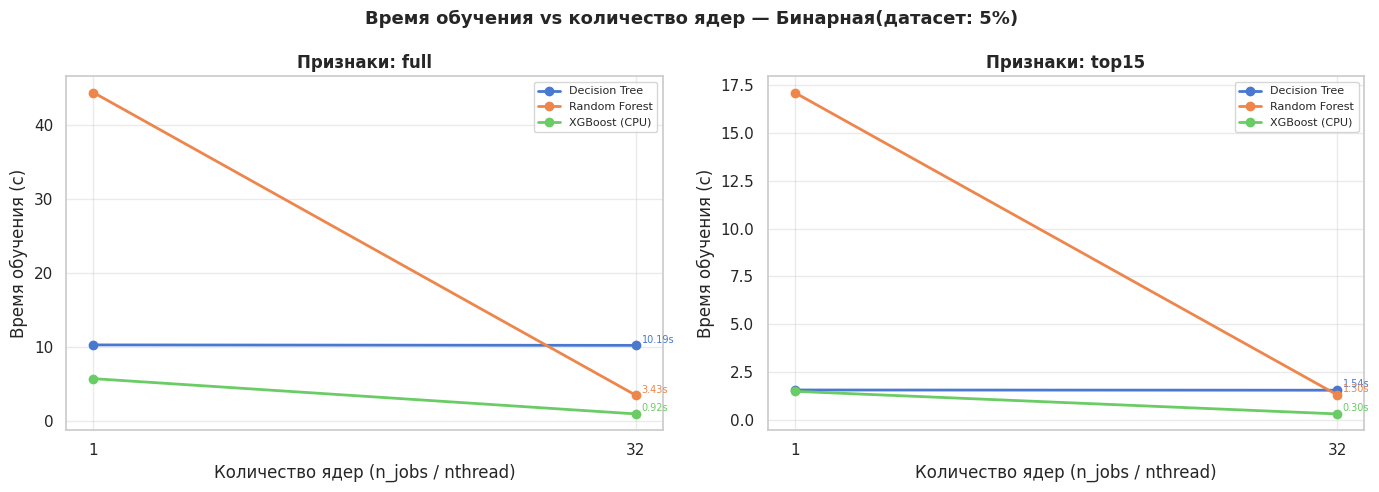

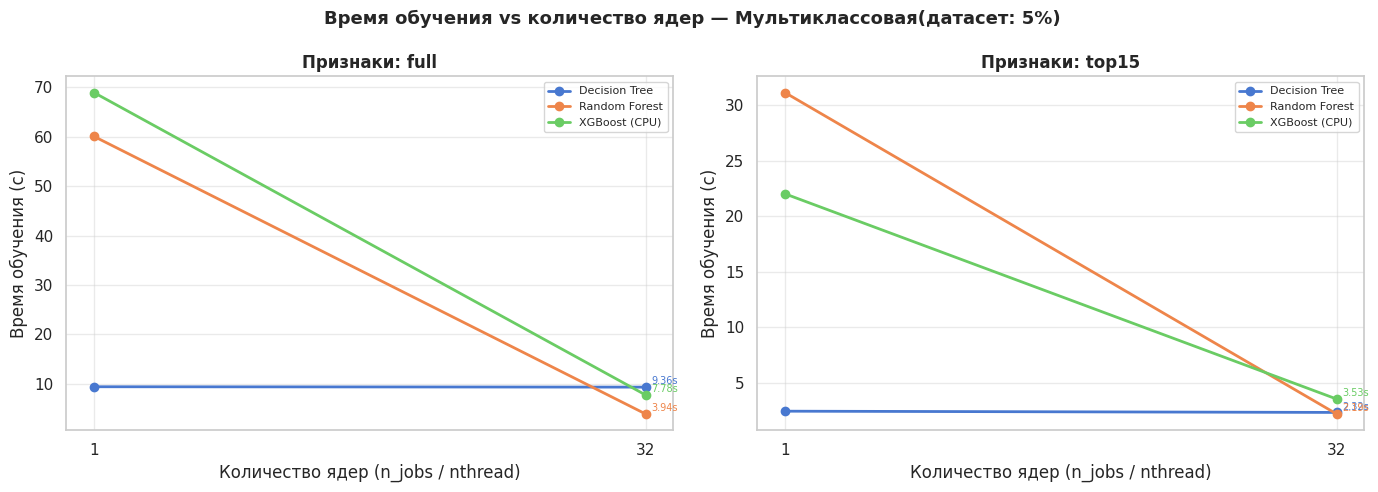


Ускорение vs 1 ядро (все признаки, бинарная задача)
Алгоритм                       1        32
--------------------------------------------
Decision Tree           x  1.00  x  1.01
Random Forest           x  1.00  x 12.93
XGBoost (CPU)           x  1.00  x  6.20
\Время обучения (с) (все признаки, бинарная задача)
Алгоритм                       1        32
--------------------------------------------
Decision Tree             10.251    10.189
Random Forest             44.379     3.432
XGBoost (CPU)              5.688     0.918


In [43]:
import psutil as _psutil
_logi_cores = _psutil.cpu_count(logical=True)

def _cores_label(n):
    """Человекочитаемая метка для оси X"""
    return f"all({_logi_cores})" if n == -1 else str(n)

_parallel_algos = [a for a, d in PARALLEL_MODELS_DEF.items() if d["parallel_param"] is not None]
_single_algos   = [a for a, d in PARALLEL_MODELS_DEF.items() if d["parallel_param"] is None]

_feature_modes  = list(list(cores_results.values())[0][_parallel_algos[0]].keys())
_tasks          = ["binary", "multiclass"]
_task_labels    = {"binary": "Бинарная", "multiclass": "Мультиклассовая"}

_sorted_jobs    = sorted(cores_results.keys(), key=lambda x: _logi_cores if x == -1 else x)
_x_labels       = [_cores_label(n) for n in _sorted_jobs]
_x_pos          = list(range(len(_sorted_jobs)))

COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for task in _tasks:
    fig, axes = plt.subplots(1, len(_feature_modes),
                              figsize=(7 * len(_feature_modes), 5), sharey=False)
    if len(_feature_modes) == 1:
        axes = [axes]

    fig.suptitle(
        f"Время обучения vs количество ядер — {_task_labels[task]}"
        f"(датасет: {CORES_SAMPLE_FRACTION*100:.0f}%)",
        fontsize=13, fontweight="bold"
    )

    for ax, fmode in zip(axes, _feature_modes):
        for ci, algo_name in enumerate(_parallel_algos):
            times = [cores_results[n][algo_name][fmode][task] for n in _sorted_jobs]
            ax.plot(_x_pos, times, marker="o", linewidth=2,
                    label=algo_name, color=COLORS[ci])

            ax.annotate(f"{times[-1]:.2f}s",
                        xy=(_x_pos[-1], times[-1]),
                        xytext=(4, 2), textcoords="offset points",
                        fontsize=7, color=COLORS[ci])

        for ci2, algo_name in enumerate(_single_algos):
            t_ref = cores_results[_sorted_jobs[0]][algo_name][fmode][task]
            ax.axhline(t_ref, linestyle="--", linewidth=1.4,
                       color=COLORS[len(_parallel_algos) + ci2],
                       label=f"{algo_name} (однопоточный: {t_ref:.2f}s)")

        ax.set_title(f"Признаки: {fmode}", fontweight="bold")
        ax.set_xlabel("Количество ядер (n_jobs / nthread)")
        ax.set_ylabel("Время обучения (с)")
        ax.set_xticks(_x_pos)
        ax.set_xticklabels(_x_labels)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

print("\nУскорение vs 1 ядро (все признаки, бинарная задача)")
_base_n = _sorted_jobs[0]
header = "  ".join(f"{_cores_label(n):>8}" for n in _sorted_jobs)
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in _parallel_algos:
    t_base = cores_results[_base_n][algo_name]["full"]["binary"]
    row = "  ".join(
        f"x{t_base / cores_results[n][algo_name]['full']['binary']:>6.2f}"
        for n in _sorted_jobs
    )
    print(f"{algo_name:<22}  {row}")

print("\Время обучения (с) (все признаки, бинарная задача)")
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in list(PARALLEL_MODELS_DEF.keys()):
    row = "  ".join(
        f"{cores_results[n][algo_name]['full']['binary']:>8.3f}"
        for n in _sorted_jobs
    )
    print(f"{algo_name:<22}  {row}")
